### Load and parse part of dataset for use in LTR. 

In [1]:
import os 
import pyarrow.feather as feather
import pyarrow as pa
import glob


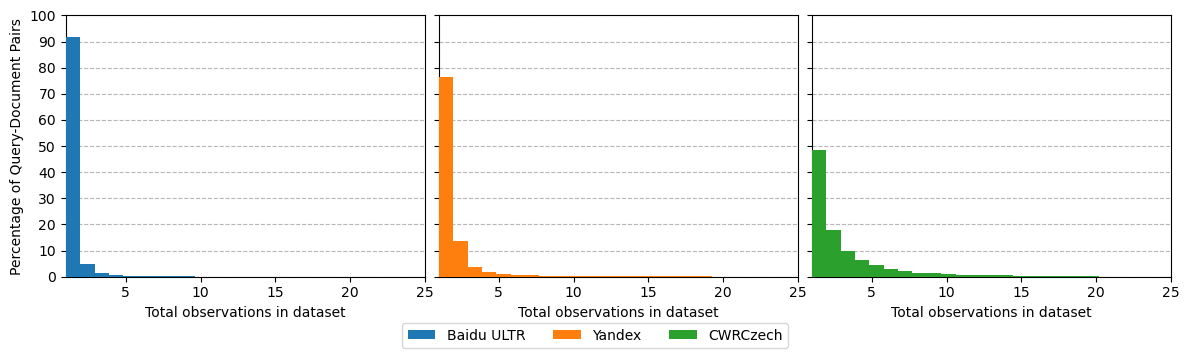

In [3]:
import json
from collections import Counter
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

base = Path("dataset_counts")
files = [
    "baidu_ultr_hist.json",
    "yandex_hist.json",
    "cwzczech_hist.json",
]

# Provide nice names corresponding to the files
nice_names = [
    "Baidu ULTR",
    "Yandex",
    "CWRCzech"
]

def load_hist(path):
    with open(path, "r") as f:
        data = json.load(f)
    return Counter({int(k): int(v) for k, v in data.items()})

def expand_hist(counter, cutoff=50):
    arr = []
    for k, v in counter.items():
        if k <= cutoff:
            arr.extend([k] * v)
    return np.array(arr)

# Figsize remains slightly increased to (12, 4)
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

for i, (ax, f, name) in enumerate(zip(axes, files, nice_names)):
    hist = load_hist(base / f)

    counts = expand_hist(hist, cutoff=25)
    weights = np.ones_like(counts) / len(counts) * 100

    ax.hist(
        counts,
        bins=25,
        range=(1, 25),
        weights=weights,
        color=f"C{i}", 
        label=name,
        zorder=3
    )

    ax.set_xlabel("Total observations in dataset")
    ax.set_xlim(1, 25)

    # Set y-axis limits to exactly 0 to 100
    ax.set_ylim(0, 100)
    # Set y-ticks from 0 to 100 in steps of 10
    ax.set_yticks(range(0, 101, 10))
    ax.grid(axis='y', linestyle='--', alpha=0.9, zorder=0)

    # Set y-axis label only for the first plot
    if ax == axes[0]:
        ax.set_ylabel("Percentage of Query-Document Pairs")

# Place one shared legend below the entire figure
handles, labels = [], []
for ax in axes:
    for h, l in zip(*ax.get_legend_handles_labels()):
        handles.append(h)
        labels.append(l)

fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, 0.1), ncol=3)
# Use w_pad=0 to move the subplots right next to each other horizontally
plt.tight_layout(rect=[0, 0.15, 1, 1], w_pad=0.0)
plt.savefig("../thesis_plots/Click_dataset_counts_histogram.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:

FEATHER_DIR = "../../../Project_AI/baidu_ultr_dataset/parts"

# ---------------------------------------------------------
# Get complete list of columns from the first feather file
# ---------------------------------------------------------
sample_file = sorted(glob.glob(f"{FEATHER_DIR}/part-*.feather"))[0]
sample_table = feather.read_table(sample_file)

# Remove ONLY the embedding column
columns = [c for c in sample_table.column_names if c != "query_document_embedding"]

# ---------------------------------------------------------
# Load all files with the filtered column list
# ---------------------------------------------------------
paths = sorted(glob.glob(f"{FEATHER_DIR}/part-*.feather"))
# remove all with part-0 in the name
paths = [p for p in paths]

tables = []
for path in paths:
    print("Loading:", path)
    table = feather.read_table(path, columns=columns)  # all except embedding
    tables.append(table)

# Merge into a single big arrow table
ltr_table = pa.concat_tables(tables, promote=True)

print(ltr_table)


Loading: ../../../Project_AI/baidu_ultr_dataset/parts/part-0_split-0.feather
Loading: ../../../Project_AI/baidu_ultr_dataset/parts/part-0_split-1.feather
Loading: ../../../Project_AI/baidu_ultr_dataset/parts/part-0_split-2.feather
Loading: ../../../Project_AI/baidu_ultr_dataset/parts/part-0_split-3.feather
Loading: ../../../Project_AI/baidu_ultr_dataset/parts/part-0_split-4.feather
Loading: ../../../Project_AI/baidu_ultr_dataset/parts/part-0_split-5.feather
Loading: ../../../Project_AI/baidu_ultr_dataset/parts/part-0_split-6.feather
Loading: ../../../Project_AI/baidu_ultr_dataset/parts/part-0_split-7.feather
Loading: ../../../Project_AI/baidu_ultr_dataset/parts/part-0_split-8.feather
Loading: ../../../Project_AI/baidu_ultr_dataset/parts/part-0_split-9.feather
Loading: ../../../Project_AI/baidu_ultr_dataset/parts/part-1_split-0.feather
Loading: ../../../Project_AI/baidu_ultr_dataset/parts/part-1_split-1.feather
Loading: ../../../Project_AI/baidu_ultr_dataset/parts/part-1_split-2.feather

/opt/homebrew/Caskroom/miniforge/base/envs/two-tower-confounding-2/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3579: FutureWarning: promote has been superseded by promote_options='default'.
  exec(code_obj, self.user_global_ns, self.user_ns)


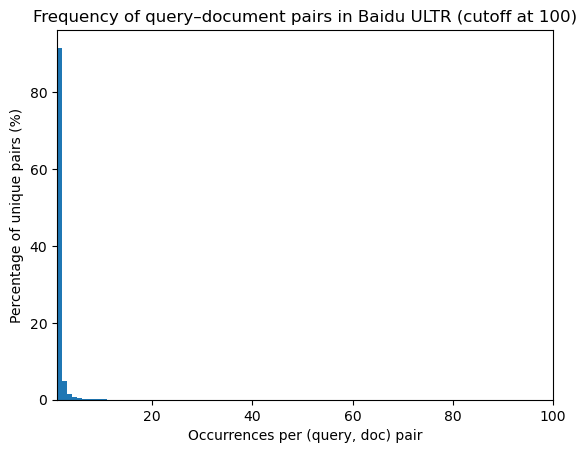

In [41]:
import pyarrow as pa
import numpy as np
import matplotlib.pyplot as plt

keys = ["query_md5", "text_md5"]

t = ltr_table.select(keys + ["position"])

pair_counts = (
    t.group_by(keys)
    .aggregate([("position", "count")])
    .rename_columns(keys + ["count"])
)

counts = pair_counts["count"].to_numpy(zero_copy_only=False)

# cut off at 100
counts = counts[counts <= 100]

# weights so histogram shows percentage
weights = np.ones_like(counts) / len(counts) * 100

plt.figure()
plt.hist(
    counts,
    bins=100,          # 1 bin per occurrence count
    range=(1, 100),
    weights=weights
)

plt.xlabel("Occurrences per (query, doc) pair")
plt.ylabel("Percentage of unique pairs (%)")
plt.title("Frequency of query–document pairs in Baidu ULTR (cutoff at 100)")
plt.xlim(1, 100)
plt.show()

In [44]:
import json
from collections import Counter

keys = ["query_md5", "text_md5"]

t = ltr_table.select(keys + ["position"])

pair_counts = (
    t.group_by(keys)
    .aggregate([("position", "count")])
    .rename_columns(keys + ["count"])
)

# This is the exact histogram type you want:
# Counter({occurrence_count: number_of_pairs_with_that_count})
hist = Counter(pair_counts["count"].to_pylist())

with open("dataset_counts/baidu_ultr_hist.json", "w") as f:
    json.dump(hist, f)

In [27]:
import duckdb

path = "../../ltr_datasets/cwrczech/train/*.parquet"

con = duckdb.connect()
con.execute("PRAGMA threads=8")  # or set to your CPU count

result = con.execute(f"""
    SELECT
        md5(
            to_json(
                struct_pack(
                    title := coalesce(title, ''),
                    query := coalesce(query, '')
                )
            )
        ) AS title_query_md5,
        count(*) AS cnt
    FROM read_parquet('{path}', union_by_name=true)
    GROUP BY 1
    ORDER BY cnt DESC
""").fetch_df()

print(result)
print(result["cnt"].value_counts().sort_index())

                           title_query_md5   cnt
0         402082193b58acd3f6fb4ba52dc85dcd  2625
1         714552d58646e181db7a24407a13419f  1674
2         b5147b3c7d14fdf0a57d06eb928964fc  1555
3         46c79fd23f1ed5e65979fd1dcb8f6549  1490
4         c64004496089ce68302c7ae4b9e09b99  1481
...                                    ...   ...
34513606  5606557e999ad5dba36c52e7310d420c     1
34513607  297caff9517d90a17cdb55826053fa55     1
34513608  a5c54043c41a077ad0b4516874421639     1
34513609  f239476f811dcebedec49a0bf821b886     1
34513610  d9238315f4ba012ec848834a15c46b0a     1

[34513611 rows x 2 columns]
cnt
1       16679466
2        6139884
3        3424323
4        2234376
5        1527732
          ...   
1481           1
1490           1
1555           1
1674           1
2625           1
Name: count, Length: 475, dtype: int64


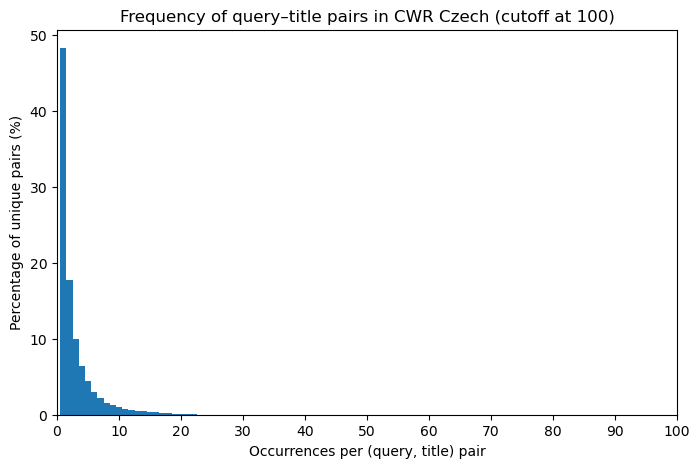

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# counts per unique (title, query) pair
counts = result["cnt"].to_numpy()

# cut off at 100
counts = counts[counts <= 100]

# weights so histogram shows percentage of unique pairs
weights = np.ones_like(counts, dtype=np.float64) / len(counts) * 100

plt.figure(figsize=(8, 5))
plt.hist(
    counts,
    bins=np.arange(1, 102) - 0.5,   # one bin per integer count from 1..100
    range=(1, 100),
    weights=weights
)

plt.xlabel("Occurrences per (query, title) pair")
plt.ylabel("Percentage of unique pairs (%)")
plt.title("Frequency of query–title pairs in CWR Czech (cutoff at 100)")
plt.xlim(1, 100)
plt.xticks(np.arange(0, 101, 10))
plt.show()

In [ ]:
from collections import Counter
import json

# Build histogram of the cnt column
hist_cwzczech = Counter(result["cnt"])

with open("dataset_counts/cwzczech_hist.json", "w") as f:
    json.dump(hist_cwzczech, f


In [35]:
from collections import Counter
import json

with open("dataset_counts/cwzczech_hist.json", "r") as f:
    hist_cwzczech = Counter({int(k): v for k, v in json.load(f).items()})

In [5]:
import gzip
import shutil
with gzip.open('../../ltr_datasets/yandex-personalized-web-search-challenge/train.gz', 'rb') as f_in:
    with open('file.txt', 'wb') as f_out:
        shutil.copyfileobj(f_in, f_out)

Temporary bucket dir: /var/folders/nb/j_h4xjxd1tl7g7169hm8cdnc0000gn/T/yandex_qd_buckets_4jso08e_
Using 1024 buckets
[partition 0.50/15.34 GB] lines=5,481,075 Q-lines=2,164,775 pairs=21,647,750 speed=0.057 GB/s elapsed=8.7s
[partition 1.00/15.34 GB] lines=10,902,612 Q-lines=4,306,416 pairs=43,064,160 speed=0.058 GB/s elapsed=17.4s
[partition 1.50/15.34 GB] lines=16,325,515 Q-lines=6,448,024 pairs=64,480,240 speed=0.057 GB/s elapsed=26.2s
[partition 2.00/15.34 GB] lines=21,747,065 Q-lines=8,589,768 pairs=85,897,680 speed=0.057 GB/s elapsed=35.2s
[partition 2.50/15.34 GB] lines=27,171,625 Q-lines=10,731,104 pairs=107,311,040 speed=0.056 GB/s elapsed=44.3s
[partition 3.00/15.34 GB] lines=32,581,299 Q-lines=12,868,854 pairs=128,688,540 speed=0.056 GB/s elapsed=53.6s
[partition 3.50/15.34 GB] lines=37,995,572 Q-lines=15,005,464 pairs=150,054,640 speed=0.055 GB/s elapsed=63.3s
[partition 4.00/15.34 GB] lines=43,403,914 Q-lines=17,143,215 pairs=171,432,150 speed=0.056 GB/s elapsed=72.1s
[part

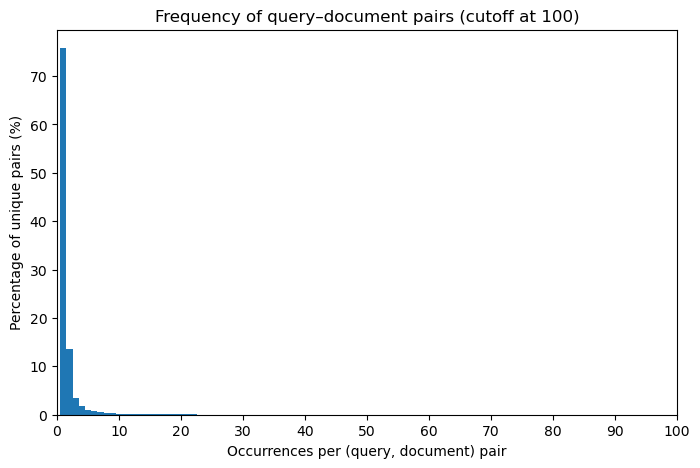

In [13]:
from collections import Counter
from pathlib import Path
import os
import time
import tempfile
import numpy as np
import matplotlib.pyplot as plt


def partition_query_doc_pairs(
    input_path: str,
    tmp_dir: str,
    n_buckets: int = 512,
    progress_every_gb: float = 0.5,
):
    """
    Pass 1:
    Stream the source file and write packed (query_id, doc_id) pairs
    into bucket files based on hash(key) % n_buckets.
    """
    tmp_path = Path(tmp_dir)
    tmp_path.mkdir(parents=True, exist_ok=True)

    bucket_paths = [tmp_path / f"bucket_{i:04d}.bin" for i in range(n_buckets)]
    bucket_files = [open(p, "wb", buffering=1024 * 1024 * 8) for p in bucket_paths]

    file_size = os.path.getsize(input_path)
    progress_every_bytes = int(progress_every_gb * 1024**3)

    bytes_read = 0
    next_progress = progress_every_bytes
    q_lines = 0
    total_pairs = 0
    line_no = 0

    t0 = time.time()

    try:
        with open(input_path, "rb", buffering=1024 * 1024 * 32) as f:
            for line_no, line in enumerate(f, 1):
                bytes_read += len(line)

                parts = line.rstrip(b"\n").split(b"\t")
                if len(parts) < 7 or parts[2] != b"Q":
                    pass
                else:
                    q_lines += 1
                    query_id = int(parts[4])

                    for field in parts[6:]:
                        comma = field.find(b",")
                        if comma == -1:
                            continue
                        doc_id = int(field[:comma])

                        key = (query_id << 32) | doc_id
                        bucket_idx = key % n_buckets
                        bucket_files[bucket_idx].write(key.to_bytes(8, "little", signed=False))
                        total_pairs += 1

                if bytes_read >= next_progress:
                    elapsed = time.time() - t0
                    gb_done = bytes_read / 1024**3
                    gb_total = file_size / 1024**3
                    speed = gb_done / elapsed if elapsed > 0 else 0
                    print(
                        f"[partition {gb_done:.2f}/{gb_total:.2f} GB] "
                        f"lines={line_no:,} Q-lines={q_lines:,} pairs={total_pairs:,} "
                        f"speed={speed:.3f} GB/s elapsed={elapsed:.1f}s"
                    )
                    next_progress += progress_every_bytes
    finally:
        for bf in bucket_files:
            bf.close()

    elapsed = time.time() - t0
    print(
        f"\nPartitioning done in {elapsed:.1f}s | "
        f"lines={line_no:,} Q-lines={q_lines:,} pairs={total_pairs:,}"
    )

    return bucket_paths, total_pairs


def count_bucket_file(bucket_path: Path):
    """
    Count one bucket in memory.
    Returns:
      - Counter of occurrence counts (histogram of pair frequencies)
      - number of unique pairs in this bucket
      - top count in this bucket
    """
    ctr = Counter()

    with open(bucket_path, "rb", buffering=1024 * 1024 * 16) as f:
        while True:
            chunk = f.read(8 * 1_000_000)  # 8 MB worth of keys at a time
            if not chunk:
                break

            # iterate over packed 8-byte integers
            for i in range(0, len(chunk), 8):
                key = int.from_bytes(chunk[i:i+8], "little", signed=False)
                ctr[key] += 1

    hist = Counter(ctr.values())
    n_unique = len(ctr)
    max_cnt = max(ctr.values(), default=0)

    return hist, n_unique, max_cnt


def count_partitioned(
    input_path: str,
    n_buckets: int = 512,
    progress_every_gb: float = 0.5,
    max_count_cutoff: int = 100,
    tmp_dir: str | None = None,
):
    if tmp_dir is None:
        tmp_dir = tempfile.mkdtemp(prefix="yandex_qd_buckets_")

    print(f"Temporary bucket dir: {tmp_dir}")
    print(f"Using {n_buckets} buckets")

    bucket_paths, total_pairs = partition_query_doc_pairs(
        input_path=input_path,
        tmp_dir=tmp_dir,
        n_buckets=n_buckets,
        progress_every_gb=progress_every_gb,
    )

    global_hist = Counter()
    total_unique = 0
    global_max_cnt = 0

    t1 = time.time()

    for idx, bucket_path in enumerate(bucket_paths, 1):
        size_mb = bucket_path.stat().st_size / 1024**2

        if bucket_path.stat().st_size == 0:
            print(f"[count {idx}/{len(bucket_paths)}] empty")
            continue

        hist, n_unique, max_cnt = count_bucket_file(bucket_path)

        global_hist.update(hist)
        total_unique += n_unique
        global_max_cnt = max(global_max_cnt, max_cnt)

        print(
            f"[count {idx}/{len(bucket_paths)}] "
            f"{bucket_path.name} size={size_mb:.1f} MB "
            f"unique={n_unique:,} max_cnt={max_cnt}"
        )

        # optional cleanup to save disk
        bucket_path.unlink()

    elapsed = time.time() - t1
    print(f"\nCounting buckets done in {elapsed:.1f}s")
    print(f"Total emitted pairs: {total_pairs:,}")
    print(f"Total unique pairs: {total_unique:,}")
    print(f"Max pair count: {global_max_cnt}")

    print("\nValue counts (occurrences -> number of unique pairs):")
    for occ in sorted(global_hist):
        print(f"{occ}\t{global_hist[occ]}")

    # Plot, in the same style as before
    xs = np.array(sorted(k for k in global_hist if k <= max_count_cutoff), dtype=np.int32)
    ys = np.array([global_hist[k] for k in xs], dtype=np.int64)

    if ys.sum() > 0:
        percentages = ys / ys.sum() * 100

        plt.figure(figsize=(8, 5))
        plt.bar(xs, percentages, width=1.0)
        plt.xlabel("Occurrences per (query, document) pair")
        plt.ylabel("Percentage of unique pairs (%)")
        plt.title(f"Frequency of query–document pairs (cutoff at {max_count_cutoff})")
        plt.xlim(1, max_count_cutoff)
        plt.xticks(np.arange(0, max_count_cutoff + 1, 10))
        plt.show()

    return global_hist


# Run
hist = count_partitioned(
    input_path="file.txt",
    n_buckets=1024,          # safer than 512 for this dataset
    progress_every_gb=0.5,
    max_count_cutoff=100,
)

In [ ]:
import json

with open("dataset_counts/yandex_hist.json", "w") as f:
    json.dump(hist, f)

In [ ]:
import json
from collections import Counter

with open("dataset_counts/yandex_hist.json", "r") as f:
    hist = Counter({int(k): v for k, v in json.load(f).items()})